<a href="https://colab.research.google.com/github/alexanderson522/INFO648/blob/main/FinalProject/INFO648_Final_Project_AA_JK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INFO 648 - Final Project
Alex Anderson, Jared Kline

#Part 1 - Business Understanding
We are data scientists at the Dept of Economic Development. We want to predict future neighborhood growth so we can properly allocate funding to growing areas. In order to properly allocate funding to growing population centers, we first have to identify which areas will actually grow.

<br>

**Target Definition:**

We will compute the growth percentage as follows:
$$ \text{growth_pct} = \frac{{pop_{2020}} - {pop_{2010}}}{{pop_{2010}}} \times 100 $$

Using `growth_pct`, we will populate our binary variable `growth`:

`growth=1` if `growth_pct>0`

`growth=o` if `growth_pct>0`

<br>

**Success Criterion:**
We will consider our model a success if our classifier beats the majority-class baseline by **0.1** on AUC (e.g. AUC >= **0.6**)

In [145]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Part 2 - Data Understanding

Observe the overall data before diving in. Our assigned division is the Mid Atlantic, which is made up of New Jersey, New York, and Pennsylvania.

In [112]:
#read in raw data
raw_data = pd.read_csv('/content/student_tracts_raw.csv')
raw_data.shape
#~73k rows

(73057, 49)

In [113]:
#drop na rows
new_data = raw_data.dropna().copy()
new_data.shape
#dropped ~300 rows

(72739, 49)

In [114]:
#create initial growth_pct field and growth target field
new_data["growth_pct"] = (new_data["pop_total_2020"] - new_data["pop_total_2010"]) / new_data["pop_total_2010"] * 100
new_data["growth"] = (new_data["growth_pct"] > 0).astype(int)

In [115]:
#filter for mid atalantic states
mid_atlantic_states = ['New Jersey', 'New York', 'Pennsylvania']
Mid_atl_data = new_data[new_data['STATE'].isin(mid_atlantic_states)].copy()

#show unique states in df
Mid_atl_data['STATE'].unique()

array(['New Jersey', 'New York', 'Pennsylvania'], dtype=object)

In [116]:
Mid_atl_data.shape
#leaves us with ~10k tracts

(10121, 51)

In [117]:
df = Mid_atl_data.copy()#create a more manageable df name for coding

In [118]:
#initial Class Balance
class_balance = df["growth"].value_counts(normalize=True).sort_index()
print("Class balance (0 = lost/no gain, 1 = grew):")
print(class_balance)

Class balance (0 = lost/no gain, 1 = grew):
growth
0    0.382867
1    0.617133
Name: proportion, dtype: float64


Our region-wide class balance shows that 61.7% of all tracts in the region have experienced growth from 2010 to 2020. This is a moderately good class balance, the positives are slightly higher, but not terribly so.

In [133]:
#list region's states by percentage of growing tracts
state_growth_percentage = df.groupby('STATE')['growth'].mean() * 100

print("Mid Atlantic States by % of Tracts with Growth:")
print(state_growth_percentage.nlargest(3))

Mid Atlantic States by % of Tracts with Growth:
STATE
New Jersey      70.885443
New York        63.615702
Pennsylvania    53.097622
Name: growth, dtype: float64


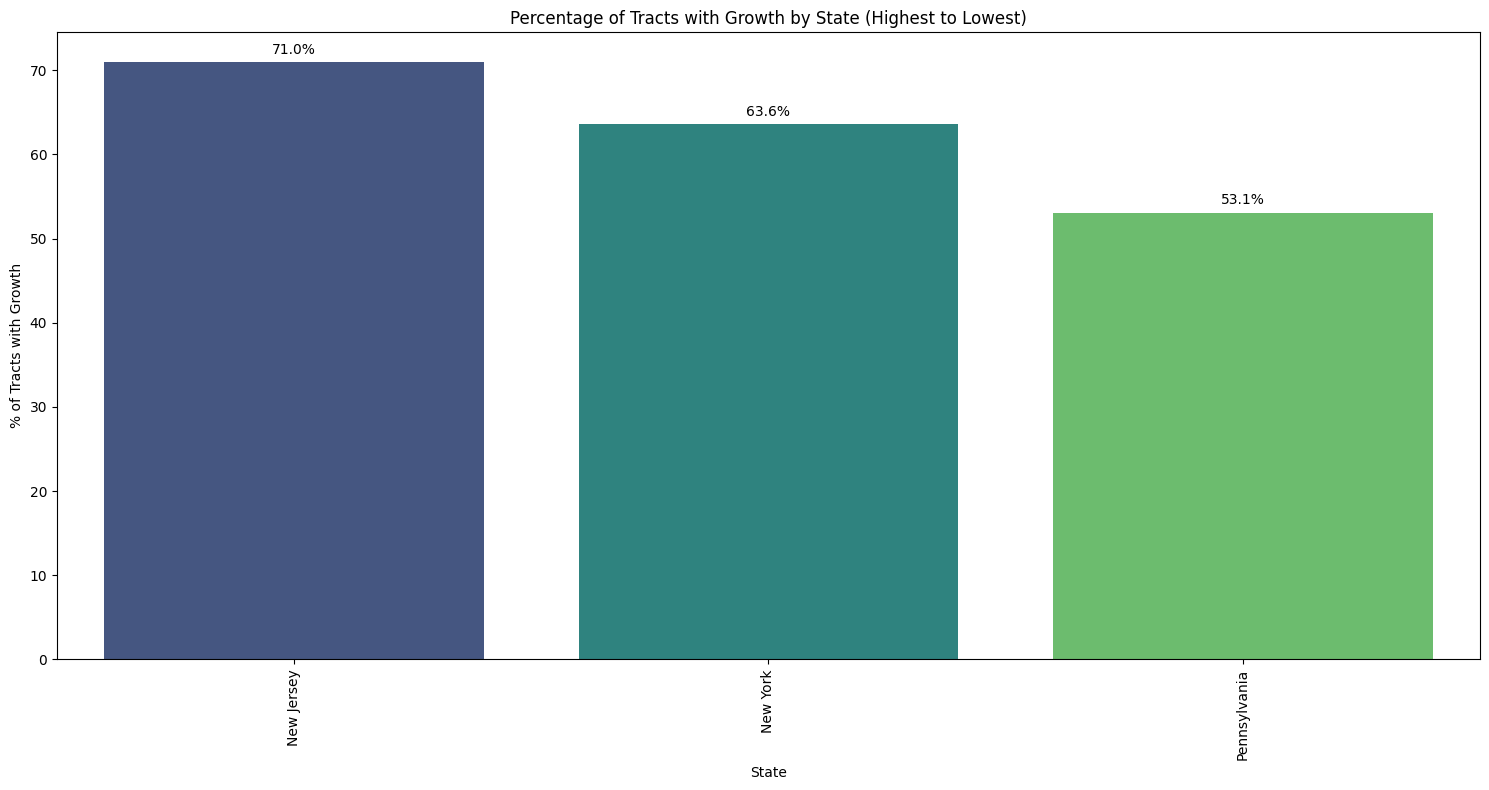

In [120]:
plt.figure(figsize=(15, 8))
sorted_state_growth_percentage = state_growth_percentage.sort_values(ascending=False)
ax = sns.barplot(x=sorted_state_growth_percentage.index, y=sorted_state_growth_percentage.values, hue=sorted_state_growth_percentage.index, palette='viridis', legend=False)
plt.title('Percentage of Tracts with Growth by State (Highest to Lowest)')
plt.xlabel('State')
plt.ylabel('% of Tracts with Growth')
plt.xticks(rotation=90)

# Add percentage labels above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

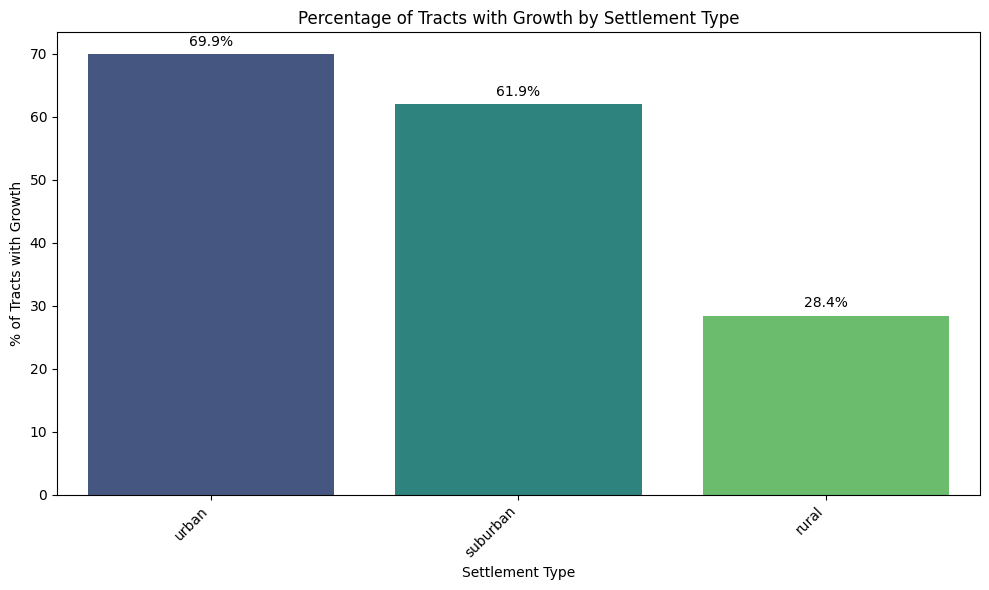

In [121]:
# check % of tracts with growth broken down by settlement type
settlement_growth_percentage = df.groupby('settlement_type')['growth'].mean() * 100

plt.figure(figsize=(10, 6))
sorted_settlement_growth_percentage = settlement_growth_percentage.sort_values(ascending=False)
ax = sns.barplot(x=sorted_settlement_growth_percentage.index, y=sorted_settlement_growth_percentage.values, hue=sorted_settlement_growth_percentage.index, palette='viridis', legend=False)
plt.title('Percentage of Tracts with Growth by Settlement Type')
plt.xlabel('Settlement Type')
plt.ylabel('% of Tracts with Growth')
plt.xticks(rotation=45, ha='right')

# Add percentage labels above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

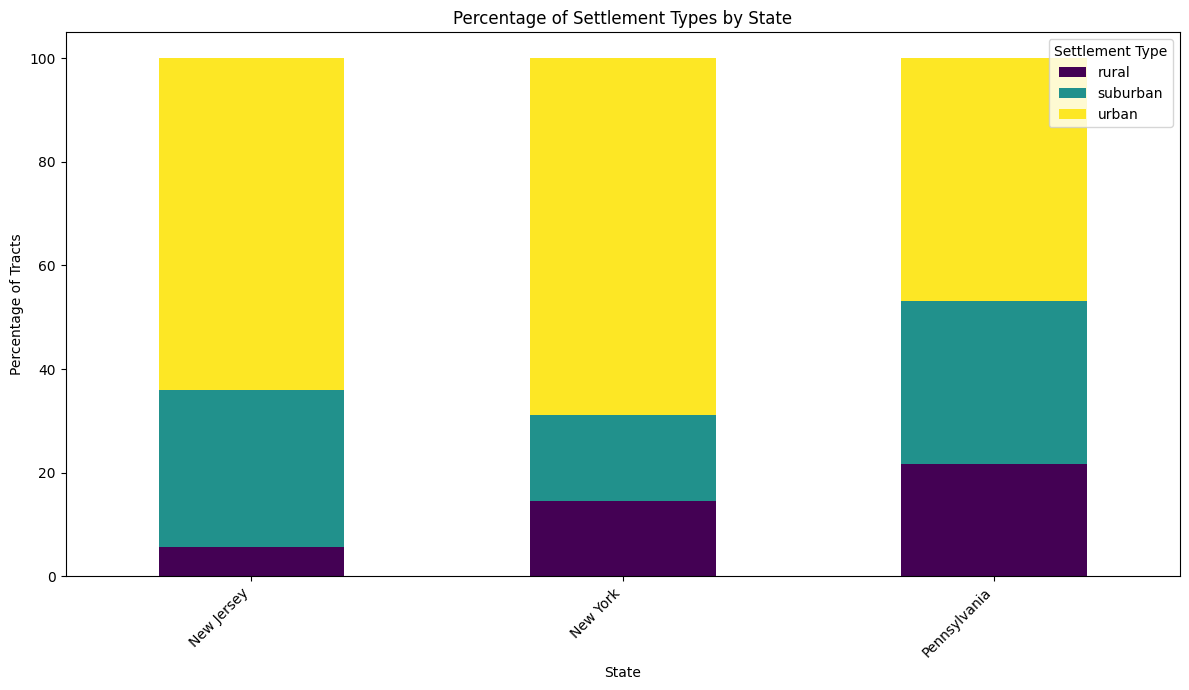

In [122]:
# Calculate the count of each settlement type within each state
settlement_type_counts_by_state = df.groupby(['STATE', 'settlement_type']).size().unstack(fill_value=0)

# Calculate the percentage of each settlement type within each state
settlement_type_percentage_by_state = settlement_type_counts_by_state.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the stacked bar chart with percentages
plt.figure(figsize=(12, 7))
settlement_type_percentage_by_state.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Percentage of Settlement Types by State')
plt.xlabel('State')
plt.ylabel('Percentage of Tracts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Settlement Type')
plt.tight_layout()
plt.show()

We can see a lot of interesting information in our initial view of the region data. First, we can see that 61.7% of the 10,121 tracts in this region had seen growth from 2010 to 2020. Second, we can see that there is significant differences in growth between the states. New Jersey and New York both had a fairly high percentage of tracts experience growth from 2010 to 2020, 71.9% and 63.6% respectively, but Pennsylvania only saw 53.1% of tracts have growth in the same time.

<br>

Additionally, we also looked growth rates by settlement type showed a very stark difference. Suburban and Urban settlement types both have a high % of tracts with growth, whereas only 26.4% of rural tracts in the region saw any growth. This likely helps explain why Pennsylvania has a lower tract growth percentage than the other two states, as it has a noticeably higher percent of rural settlement types compared to NJ and NY.

#Part 3 - Data Preparation

In [123]:
#check for tracts with no population
(new_data["pop_total_2010"] == 0).sum()
#208 tracts with no population; we'll want to remove these as it is not possible to get a growth percentage for these (will divide by zero)

np.int64(208)

In [124]:
#check for tracts with no land area
(new_data["land_area_sqkm"] == 0).sum()
#0 tracts with no land

np.int64(0)

In [125]:
#check for tracts with no population
(df["pop_total_2010"] == 0).sum()
#39 mid atlantic tracts with no population

np.int64(39)

In [126]:
#check for tracts with no land area
(df["land_area_sqkm"] == 0).sum()
#0 mid atlantic tracts with no land

np.int64(0)

In [127]:
#remove 0-population tracts from df
df = df[df["pop_total_2010"] > 0].copy()

In [128]:
#set cutoff to 50; any tract with 50 or fewer people is almost certainly not an actual residential area. Keeping them in would heavily skew our percentage based results
MIN_POP_CUTOFF = 50

before = len(df)
df = df[df["pop_total_2010"] >= MIN_POP_CUTOFF].copy()
print(f"Dropped {before - len(df)} tracts under the {MIN_POP_CUTOFF}-person minimum-population cutoff.")
print(f"Remaining: {len(df):,}")

Dropped 47 tracts under the 50-person minimum-population cutoff.
Remaining: 10,035


In [129]:
#Class Balances after data cleaning/wrangling
class_balance_clean = df["growth"].value_counts(normalize=True).sort_index()
print("Class balance (0 = lost/no gain, 1 = grew):")
print(class_balance_clean)

Class balance (0 = lost/no gain, 1 = grew):
growth
0    0.38286
1    0.61714
Name: proportion, dtype: float64


After separating the Middle Atlantic region and filtering out tracts under the population cutoff, we have a class balance of 61.7%, same as our pre-cleaning class balance.

In [139]:
#Build per-tract rate features

#housing rates
df['total_housing_units_2010'] = df['housing_occupied_2010'] + df['housing_vacant_2010']
df['pct_vacant'] = df['housing_vacant_2010'] / df['total_housing_units_2010'] * 100
df['pct_owner_occ'] = df['housing_owner_occ_2010'] / df['housing_occupied_2010'] * 100
df['pct_renter_occ'] = df['housing_renter_occ_2010'] / df['housing_occupied_2010'] * 100

#population age rates
df['pct_under18'] = (df['age_under5_2010'] + df['age_5to9_2010'] + df['age_10to14_2010'] + df['age_15to17_2010']) / df['pop_total_2010'] * 100
df['pct_18to34'] = (df['age_18to19_2010'] + df['age_20_2010'] + df['age_21_2010'] + df['age_22to24_2010'] + df['age_25to29_2010'] + df['age_30to34_2010']) / df['pop_total_2010'] * 100
df['pct_35to64'] = (df['age_35to39_2010'] + df['age_40to44_2010'] + df['age_45to49_2010'] + df['age_50to54_2010'] + df['age_55to59_2010'] + df['age_60to61_2010'] + df['age_62to64_2010']) / df['pop_total_2010'] * 100
df['pct_65plus'] = (df['age_65to69_2010'] + df['age_70to74_2010'] + df['age_75to79_2010'] + df['age_80to84_2010'] + df['age_85plus_2010']) / df['pop_total_2010'] * 100

#demographic rates
df['pct_nhwhite'] = df['race_nhwhite_2010'] / df['pop_total_2010'] * 100
df['pct_nhblack'] = df['race_nhblack_2010'] / df['pop_total_2010'] * 100
df['pct_nhapi'] = df['race_nhapi_2010'] / df['pop_total_2010'] * 100
df['pct_hispanic'] = (df['race_hispwhite_2010'] + df['race_hispblack_2010'] + df['race_hispaian_2010'] + df['race_hispapi_2010'] + df['race_hispother_2010'] + df['race_hisptwo_2010']) / df['pop_total_2010'] * 100


df['density_2010'] = df['density_perkm2']

# df[['pct_vacant','pct_owner_occ','pct_renter_occ','pct_under18','pct_18to34','pct_35to64','pct_65plus']].describe()

In [140]:
#a few tracts have zero occupied housing units, which makes the housing rates undefined - drop those too
bad_rates = df[['pct_vacant','pct_owner_occ','pct_renter_occ']].isin([np.inf,-np.inf]).any(axis=1) | df[['pct_vacant','pct_owner_occ','pct_renter_occ']].isna().any(axis=1)
df = df[~bad_rates].copy()
print(f"Final tract count going into modeling: {len(df)}")

Final tract count going into modeling: 10016


In [141]:
#identify numeric vs categorical features
numeric_features = ['pct_vacant','pct_owner_occ','pct_renter_occ','pct_under18','pct_18to34',
                     'pct_35to64','pct_65plus','pct_nhwhite','pct_nhblack','pct_nhapi',
                     'pct_hispanic','density_2010']

categorical_features = ['settlement_type','STATE']

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['pct_vacant', 'pct_owner_occ', 'pct_renter_occ', 'pct_under18', 'pct_18to34', 'pct_35to64', 'pct_65plus', 'pct_nhwhite', 'pct_nhblack', 'pct_nhapi', 'pct_hispanic', 'density_2010']
Categorical features: ['settlement_type', 'STATE']


In [142]:
#split data into training set and testing set
#Want to split before any scaling or clustering
X = df[numeric_features + categorical_features]
y = df['growth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)#stratify to keep a similar class balance

print(f"Training set: {len(X_train)} tracts")
print(f"Test set: {len(X_test)} tracts")

Training set: 7512 tracts
Test set: 2504 tracts


The features have been converted to per-tract rates for housing, age, and demographic rates. These per-tract features are then used as the numeric features when building our model(s). Categorical features (Settlement type, state) have been identified and will be one-hot encoded in the next section.

#Part 4 - Modeling

## Pipeline without clustering

In [149]:
#preprocessor for the WITHOUT cluster pipeline
preprocess_without_cluster = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) #one hot encoding on categorical features handled here
    ])

##Clustering and Scaling

In [147]:
#elbow method using inertia (distortion) to pick k - train only
distortions = []
k_range = range(1,11)

for i in k_range:
    elbow_pipeline = Pipeline([
        ('prep', ColumnTransformer(transformers=[('num', MinMaxScaler(), numeric_features)])),
        ('cluster', KMeans(n_clusters=i, random_state=42, n_init=10))
    ])
    elbow_pipeline.fit(X_train[numeric_features])
    distortions.append(elbow_pipeline.named_steps['cluster'].inertia_)
    print(f"clusters {i}: {elbow_pipeline.named_steps['cluster'].inertia_:.2f}")

clusters 1: 3093.60
clusters 2: 1583.28
clusters 3: 1271.13
clusters 4: 1024.80
clusters 5: 917.06
clusters 6: 827.49
clusters 7: 770.22
clusters 8: 719.26
clusters 9: 678.65
clusters 10: 646.08


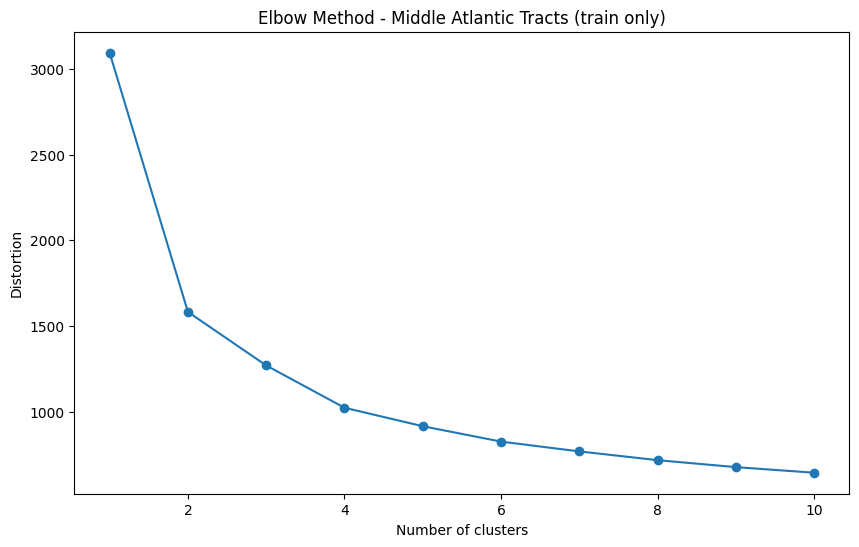

In [152]:
plt.figure(figsize=(10,6))
plt.plot(list(k_range), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method - Middle Atlantic Tracts (train only)')
plt.show()

It appears that the elbow has started to flatten around k=4. While distortion continues to drop after k=4, the rate of decrease slows down pretty dramatically. We'll use k=4, 4 neighborhood types is a good amount with significant distinctions between them.

In [153]:
#build the final clustering pipeline with our chosen k, fit on train only
cluster_preprocessor = ColumnTransformer(
    transformers=[('num', MinMaxScaler(), numeric_features)]
)

cluster_pipeline = Pipeline([
    ('prep', cluster_preprocessor),
    ('cluster', KMeans(n_clusters=4, random_state=42, n_init=20))
])

cluster_pipeline.fit(X_train[numeric_features])

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['pct_vacant',
                                                   'pct_owner_occ',
                                                   'pct_renter_occ',
                                                   'pct_under18', 'pct_18to34',
                                                   'pct_35to64', 'pct_65plus',
                                                   'pct_nhwhite', 'pct_nhblack',
                                                   'pct_nhapi', 'pct_hispanic',
                                                   'density_2010'])])),
                ('cluster', KMeans(n_clusters=4, n_init=20, random_state=42))])

In [154]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['cluster'] = cluster_pipeline.predict(X_train[numeric_features])
X_test['cluster'] = cluster_pipeline.predict(X_test[numeric_features])

X_train['cluster'].value_counts()

,count
cluster,
3,4003
0,1768
1,932
2,809


In [155]:
#pull the centroids (still in scaled 0-1 units) and the fitted scaler out of the pipeline
centroids = cluster_pipeline.named_steps['cluster'].cluster_centers_
scaler = cluster_pipeline.named_steps['prep'].named_transformers_['num']

#convert centroids back into original units
centroids_original = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_original, columns=numeric_features).round(1)
centroids_df['n_tracts_train'] = X_train['cluster'].value_counts().sort_index().values
centroids_df


,pct_vacant,pct_owner_occ,pct_renter_occ,pct_under18,pct_18to34,pct_35to64,pct_65plus,pct_nhwhite,pct_nhblack,pct_nhapi,pct_hispanic,density_2010,n_tracts_train
0,9.7,42.0,58.0,19.4,30.4,37.0,13.2,65.2,9.4,9.6,12.9,8103.2,1768
1,7.7,22.9,77.1,25.3,28.8,36.8,9.2,14.3,19.5,10.6,52.7,18146.6,932
2,10.9,44.3,55.7,25.6,24.8,38.2,11.4,9.3,71.8,2.9,12.7,8999.5,809
3,9.1,80.3,19.7,22.1,17.8,43.5,16.6,86.7,3.3,3.7,4.7,1148.4,4003


**Cluster Interpretation:**

* Cluster 0 - moderate density (~8100/km^2), 65% non-hispanic white, low percentage of black/asian/hispanic population. 30% are aged 18-34, 37% are aged 35-64. 42% home ownership. This cluster likely refers to the suburban areas located right outside city centers.

* Cluster 1 - extremely high density (~18,000/km^2), 77% renter, only 7.7% home vacancy. This cluster represents our urban cores (NYC boroughs, NJ areas right over the river from NYC, etc.)

* Cluster 2 - moderate density(~9000/km^2), very similar to cluster 0 in age and owner rates, except 72% black. This cluster has likely captured historically black urban/semi-suburban neighborhoods

* Cluster 3 - Extremely low density (~1100/km^2), 80% home ownership, 87% non-hispanic white. This cluster is our low-density suburbs and rural areas

In [162]:
#how does growth differ by cluster, for context
X_train.assign(growth=y_train.values).groupby('cluster')['growth'].mean()

,growth
cluster,
0,0.734163
1,0.729614
2,0.711990
3,0.521359


Looking at the growth/class balance within each of our clusters further confirms cluster 3 as being primarily low-density suburban or rural. As seen in our initial exploration of the data, rural settlement types (i.e. low-density areas) had a significantly lower % of tracts that experienced growth compared to urban and suburban tracts.

## Build model(s)

In [164]:
#categorical list for the with-cluster version
cat_with_cluster = ['settlement_type','STATE','cluster']

preprocess_with_cluster = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_with_cluster)
    ])

In [165]:
#Logistic Regression Models

#With Cluster
LR_cluster = Pipeline([
    ('prep', preprocess_with_cluster),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])
LR_cluster.fit(X_train, y_train)

#Without Cluster
LR_without_cluster = Pipeline([
    ('prep', preprocess_without_cluster),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])
LR_without_cluster.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['pct_vacant',
                                                   'pct_owner_occ',
                                                   'pct_renter_occ',
                                                   'pct_under18', 'pct_18to34',
                                                   'pct_35to64', 'pct_65plus',
                                                   'pct_nhwhite', 'pct_nhblack',
                                                   'pct_nhapi', 'pct_hispanic',
                                                   'density_2010']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['settlement_type',
                                                   'STATE'])])),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])